In [4]:
# ============================================================
# 4.3 IDENTIFICACIÓN Y DESCRIPCIÓN DE VARIABLES
# ============================================================
# En este notebook se trabajará con las bases procesadas
# obtenidas después de la etapa de limpieza y preprocesamiento.
#
# El objetivo será:
# 1. Identificar las variables relevantes para el estudio.
# 2. Clasificarlas según su naturaleza y función.
# 3. Describir su disponibilidad y características.
# 4. Preparar las variables numéricas para la matriz de correlación.
# ============================================================

import pandas as pd
import numpy as np
import os

# Ruta donde se encuentran las bases procesadas.
ruta_procesados = "../data/processed"

print("Entorno preparado correctamente.")

Entorno preparado correctamente.


In [5]:
# ============================================================
# PASO 2. CARGA DE LAS BASES PROCESADAS
# ============================================================
# Los identificadores como RUC y CPC se cargan como texto,
# ya que representan códigos de identificación y no cantidades.
# Esto evita perder ceros iniciales o tratarlos erróneamente
# como variables numéricas.
# ============================================================

procedimientos_df = pd.read_csv(
    os.path.join(
        ruta_procesados,
        "01_procedimientos_limpios_2025.csv"
    ),
    dtype={
        "buyer_ruc": "string",
        "buyer_ruc_valido": "string"
    }
)

oferentes_df = pd.read_csv(
    os.path.join(
        ruta_procesados,
        "02_participacion_oferentes_limpia_2025.csv"
    ),
    dtype={
        "ruc_oferente_validado": "string"
    }
)

adjudicaciones_df = pd.read_csv(
    os.path.join(
        ruta_procesados,
        "03_adjudicaciones_limpias_2025.csv"
    ),
    dtype={
        "supplier_ruc": "string",
        "supplier_ruc_validado": "string",
        "cpc_id": "string",
        "cpc_5": "string"
    }
)

print("Procedimientos:", procedimientos_df.shape)
print("Participación de oferentes:", oferentes_df.shape)
print("Adjudicaciones:", adjudicaciones_df.shape)

Procedimientos: (18326, 20)
Participación de oferentes: (79425, 8)
Adjudicaciones: (15718, 27)


In [21]:
# ============================================================
# PASO 3. REVISIÓN DE VARIABLES Y TIPOS DE DATOS
# ============================================================
# En este paso se revisan las variables disponibles en cada
# una de las tres bases procesadas y el tipo de dato con el
# que fueron cargadas en Python.
#
# Esta revisión permite distinguir:
# - variables de identificación,
# - variables categóricas,
# - variables numéricas,
# - variables temporales,
# - variables booleanas.
#
# También permite comprobar que los RUC y códigos CPC se
# mantengan como texto, ya que son identificadores y no
# cantidades numéricas.
# ============================================================

print("=" * 70)
print("VARIABLES DE LA BASE DE PROCEDIMIENTOS")
print("=" * 70)

for columna in procedimientos_df.columns:
    print(
        f"{columna:<40} "
        f"{str(procedimientos_df[columna].dtype):<15}"
    )


print("\n" + "=" * 70)
print("VARIABLES DE LA BASE DE PARTICIPACIÓN DE OFERENTES")
print("=" * 70)

for columna in oferentes_df.columns:
    print(
        f"{columna:<40} "
        f"{str(oferentes_df[columna].dtype):<15}"
    )


print("\n" + "=" * 70)
print("VARIABLES DE LA BASE DE ADJUDICACIONES")
print("=" * 70)

for columna in adjudicaciones_df.columns:
    print(
        f"{columna:<40} "
        f"{str(adjudicaciones_df[columna].dtype):<15}"
    )


# ------------------------------------------------------------
# Control específico de identificadores
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CONTROL DE TIPOS DE IDENTIFICADORES")
print("=" * 70)

print(
    "RUC comprador:",
    procedimientos_df["buyer_ruc"].dtype
)

print(
    "RUC oferente validado:",
    oferentes_df["ruc_oferente_validado"].dtype
)

print(
    "RUC proveedor validado:",
    adjudicaciones_df["supplier_ruc_validado"].dtype
)

print(
    "Código CPC:",
    adjudicaciones_df["cpc_id"].dtype
)

print(
    "Código CPC a 5 dígitos:",
    adjudicaciones_df["cpc_5"].dtype
)

VARIABLES DE LA BASE DE PROCEDIMIENTOS
ocid                                     str            
release_date                             str            
buyer_id                                 str            
buyer_name                               str            
tender_id                                str            
tender_status                            str            
number_of_tenderers                      float64        
buyer_name_normalized                    str            
buyer_ruc                                string         
release_date_dt                          str            
release_year                             int64          
buyer_ruc_valido                         string         
tender_value                             float64        
tender_currency                          str            
tender_value_source                      str            
tender_start_date                        str            
tender_start_year_local                  int64   

In [22]:
# ============================================================
# PASO 4. SELECCIÓN INICIAL DE VARIABLES PARA EL ANÁLISIS
# ============================================================
# En este paso se identifican las variables que tienen una
# función directa dentro del proyecto.
#
# No se eliminan columnas de las bases procesadas.
# Únicamente se construye un inventario de las variables
# relevantes para:
# - describir los procedimientos,
# - identificar compradores, oferentes y proveedores,
# - analizar competencia y montos,
# - estudiar recurrencia,
# - construir posteriormente la red comprador-proveedor.
# ============================================================

variables_analiticas = pd.DataFrame([

    # --------------------------------------------------------
    # BASE DE PROCEDIMIENTOS
    # --------------------------------------------------------
    [
        "Procedimientos",
        "ocid",
        "Identificación del procedimiento"
    ],

    [
        "Procedimientos",
        "buyer_id",
        "Identificación del comprador"
    ],

    [
        "Procedimientos",
        "buyer_name",
        "Descripción del comprador"
    ],

    [
        "Procedimientos",
        "buyer_ruc",
        "Identificación del comprador"
    ],

    [
        "Procedimientos",
        "number_of_tenderers",
        "Participación / competencia"
    ],

    [
        "Procedimientos",
        "tender_value",
        "Variable monetaria"
    ],

    [
        "Procedimientos",
        "tender_start_date",
        "Variable temporal"
    ],

    [
        "Procedimientos",
        "tiene_adjudicacion",
        "Resultado descriptivo del procedimiento"
    ],

    # --------------------------------------------------------
    # BASE DE PARTICIPACIÓN DE OFERENTES
    # --------------------------------------------------------
    [
        "Participación de oferentes",
        "ocid",
        "Identificación del procedimiento"
    ],

    [
        "Participación de oferentes",
        "tenderer_id",
        "Identificación del oferente"
    ],

    [
        "Participación de oferentes",
        "nombre_oferente_limpio",
        "Descripción del oferente"
    ],

    [
        "Participación de oferentes",
        "ruc_oferente_validado",
        "Identificación del oferente"
    ],

    # --------------------------------------------------------
    # BASE DE ADJUDICACIONES
    # --------------------------------------------------------
    [
        "Adjudicaciones",
        "ocid",
        "Identificación del procedimiento"
    ],

    [
        "Adjudicaciones",
        "award_id",
        "Identificación de la adjudicación"
    ],

    [
        "Adjudicaciones",
        "buyer_id",
        "Identificación del comprador"
    ],

    [
        "Adjudicaciones",
        "supplier_id",
        "Identificación del proveedor"
    ],

    [
        "Adjudicaciones",
        "nombre_proveedor_limpio",
        "Descripción del proveedor"
    ],

    [
        "Adjudicaciones",
        "supplier_ruc_validado",
        "Identificación del proveedor"
    ],

    [
        "Adjudicaciones",
        "award_amount",
        "Variable monetaria"
    ],

    [
        "Adjudicaciones",
        "award_date_local",
        "Variable temporal"
    ],

    [
        "Adjudicaciones",
        "cpc_5",
        "Clasificación del objeto contractual"
    ],

    [
        "Adjudicaciones",
        "cpc_description",
        "Descripción del objeto contractual"
    ]

], columns=[
    "base",
    "variable",
    "funcion_inicial"
])

print(variables_analiticas.to_string(index=False))

                      base                variable                         funcion_inicial
            Procedimientos                    ocid        Identificación del procedimiento
            Procedimientos                buyer_id            Identificación del comprador
            Procedimientos              buyer_name               Descripción del comprador
            Procedimientos               buyer_ruc            Identificación del comprador
            Procedimientos     number_of_tenderers             Participación / competencia
            Procedimientos            tender_value                      Variable monetaria
            Procedimientos       tender_start_date                       Variable temporal
            Procedimientos      tiene_adjudicacion Resultado descriptivo del procedimiento
Participación de oferentes                    ocid        Identificación del procedimiento
Participación de oferentes             tenderer_id             Identificación del oferente

In [24]:
# ============================================================
# PASO 5. VARIABLES DERIVADAS PREVISTAS PARA EL ANÁLISIS
# ============================================================
# En este paso se definen las variables que no vienen
# directamente en los archivos de SERCOP, sino que serán
# calculadas posteriormente a partir de las bases procesadas.
#
# Estas variables responden a los tres componentes principales
# del proyecto:
# 1. Concentración de adjudicaciones.
# 2. Relaciones recurrentes.
# 3. Analítica de redes comprador-proveedor.
#
# La definición separa expresamente el HHI monetario del HHI
# por frecuencia, ya que representan dimensiones diferentes.
# ============================================================

variables_derivadas = pd.DataFrame([

    # --------------------------------------------------------
    # CONCENTRACIÓN POR ENTIDAD CONTRATANTE
    # --------------------------------------------------------

    [
        "Concentración",
        "numero_adjudicaciones",
        "Entidad contratante",
        "Cantidad total de adjudicaciones realizadas por cada entidad contratante."
    ],

    [
        "Concentración",
        "numero_proveedores",
        "Entidad contratante",
        "Número de proveedores distintos adjudicados por cada entidad contratante."
    ],

    [
        "Concentración",
        "hhi_monetario",
        "Entidad contratante",
        "Índice HHI calculado a partir de la participación de cada proveedor en el monto total adjudicado."
    ],

    [
        "Concentración",
        "hhi_frecuencia",
        "Entidad contratante",
        "Índice HHI calculado a partir de la participación de cada proveedor en el número de adjudicaciones."
    ],

    [
        "Concentración",
        "hhi_monetario_normalizado",
        "Entidad contratante",
        "HHI monetario normalizado considerando el número de proveedores, utilizado para comparar entidades con distinta estructura de participación."
    ],

    [
        "Concentración",
        "hhi_frecuencia_normalizado",
        "Entidad contratante",
        "HHI por frecuencia normalizado considerando el número de proveedores."
    ],

    [
        "Concentración",
        "cr4_monetario",
        "Entidad contratante",
        "Proporción del monto adjudicado acumulada por los cuatro proveedores con mayor participación en cada entidad."
    ],

    [
        "Concentración",
        "entropia_monetaria",
        "Entidad contratante",
        "Medida complementaria de diversidad basada en la distribución del monto adjudicado entre proveedores."
    ],

    # --------------------------------------------------------
    # RECURRENCIA
    # --------------------------------------------------------

    [
        "Recurrencia",
        "max_procesos_90d",
        "Comprador - proveedor - CPC5",
        "Máximo número de procesos registrados entre el mismo comprador, proveedor y objeto contractual CPC5 dentro de una ventana de 90 días."
    ],

    [
        "Recurrencia",
        "recurrencia_90d",
        "Comprador - proveedor - CPC5",
        "Indicador que identifica combinaciones con más de tres procesos dentro de una ventana de 90 días."
    ],

    # --------------------------------------------------------
    # RELACIONES COMPRADOR-PROVEEDOR
    # --------------------------------------------------------

    [
        "Red comprador-proveedor",
        "frecuencia_relacion",
        "Comprador - proveedor",
        "Número de adjudicaciones acumuladas entre una entidad contratante y un proveedor."
    ],

    [
        "Red comprador-proveedor",
        "monto_total_relacion",
        "Comprador - proveedor",
        "Monto total adjudicado acumulado entre una entidad contratante y un proveedor."
    ],

    [
        "Red comprador-proveedor",
        "log10_monto_total_relacion",
        "Comprador - proveedor",
        "Transformación logarítmica base 10 del monto total adjudicado, utilizada como peso de la relación en la red."
    ],

    # --------------------------------------------------------
    # MÉTRICAS DE RED
    # --------------------------------------------------------

    [
        "Métricas de red",
        "degree",
        "Actor de la red",
        "Número de conexiones directas de una entidad contratante o proveedor dentro de la red."
    ],

    [
        "Métricas de red",
        "betweenness",
        "Actor de la red",
        "Medida de intermediación que permite identificar actores que conectan diferentes partes de la red."
    ]

], columns=[
    "grupo_analitico",
    "variable_derivada",
    "unidad_analisis",
    "descripcion"
])

# Mostrar la matriz en formato de tabla dentro del notebook.
display(
    variables_derivadas.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "left",
        "white-space": "normal"
    })
)

grupo_analitico,variable_derivada,unidad_analisis,descripcion
Concentración,numero_adjudicaciones,Entidad contratante,Cantidad total de adjudicaciones realizadas por cada entidad contratante.
Concentración,numero_proveedores,Entidad contratante,Número de proveedores distintos adjudicados por cada entidad contratante.
Concentración,hhi_monetario,Entidad contratante,Índice HHI calculado a partir de la participación de cada proveedor en el monto total adjudicado.
Concentración,hhi_frecuencia,Entidad contratante,Índice HHI calculado a partir de la participación de cada proveedor en el número de adjudicaciones.
Concentración,hhi_monetario_normalizado,Entidad contratante,"HHI monetario normalizado considerando el número de proveedores, utilizado para comparar entidades con distinta estructura de participación."
Concentración,hhi_frecuencia_normalizado,Entidad contratante,HHI por frecuencia normalizado considerando el número de proveedores.
Concentración,cr4_monetario,Entidad contratante,Proporción del monto adjudicado acumulada por los cuatro proveedores con mayor participación en cada entidad.
Concentración,entropia_monetaria,Entidad contratante,Medida complementaria de diversidad basada en la distribución del monto adjudicado entre proveedores.
Recurrencia,max_procesos_90d,Comprador - proveedor - CPC5,"Máximo número de procesos registrados entre el mismo comprador, proveedor y objeto contractual CPC5 dentro de una ventana de 90 días."
Recurrencia,recurrencia_90d,Comprador - proveedor - CPC5,Indicador que identifica combinaciones con más de tres procesos dentro de una ventana de 90 días.


In [25]:
# ============================================================
# PASO 6. MATRIZ FINAL DE VARIABLES DEL ESTUDIO
# ============================================================
# La matriz organiza las principales variables utilizadas en
# el proyecto según:
# - clasificación metodológica,
# - fuente de los datos,
# - naturaleza o tipo,
# - unidad de análisis,
# - descripción.
#
# Debido al carácter descriptivo, relacional y de analítica
# de redes del proyecto, los identificadores y variables de
# contexto se clasifican como "No aplica", ya que no deben
# forzarse como variables dependientes o independientes.
#
# Las métricas de concentración, recurrencia y red se
# consideran variables de resultado del análisis.
# ============================================================

matriz_variables_final = pd.DataFrame([

    # --------------------------------------------------------
    # IDENTIFICACIÓN Y CONTEXTO
    # --------------------------------------------------------

    [
        "ocid",
        "No aplica - identificación",
        "SERCOP - Datos abiertos OCDS",
        "Categórica nominal",
        "Procedimiento",
        "Identificador único del procedimiento de contratación."
    ],

    [
        "buyer_id",
        "No aplica - identificación",
        "SERCOP - Datos abiertos OCDS",
        "Categórica nominal",
        "Entidad contratante",
        "Identificador utilizado para reconocer a la entidad contratante y construir el nodo comprador."
    ],

    [
        "supplier_id",
        "No aplica - identificación",
        "SERCOP - Datos abiertos OCDS",
        "Categórica nominal",
        "Proveedor adjudicado",
        "Identificador utilizado para reconocer al proveedor adjudicado y construir el nodo proveedor."
    ],

    [
        "tenderer_id",
        "No aplica - identificación",
        "SERCOP - Datos abiertos OCDS",
        "Categórica nominal",
        "Oferente",
        "Identificador del oferente participante en el procedimiento."
    ],

    [
        "tender_start_date",
        "No aplica - temporal",
        "SERCOP - Datos abiertos OCDS",
        "Temporal",
        "Procedimiento",
        "Fecha local de inicio utilizada para delimitar los procedimientos iniciados durante 2025."
    ],

    [
        "award_date_local",
        "No aplica - temporal",
        "SERCOP - Datos abiertos OCDS",
        "Temporal",
        "Adjudicación",
        "Fecha local de adjudicación utilizada en el análisis temporal y de recurrencia."
    ],

    [
        "cpc_5",
        "No aplica - contexto",
        "Elaboración propia a partir de SERCOP",
        "Categórica nominal",
        "Objeto contractual",
        "Código CPC agrupado a cinco dígitos para comparar procedimientos relacionados con objetos contractuales similares."
    ],

    # --------------------------------------------------------
    # VARIABLES INDEPENDIENTES / DE ENTRADA
    # --------------------------------------------------------

    [
        "number_of_tenderers",
        "Independiente / explicativa",
        "SERCOP - Datos abiertos OCDS",
        "Cuantitativa discreta",
        "Procedimiento",
        "Número de oferentes registrados en cada procedimiento, utilizado como indicador de participación."
    ],

    [
        "tender_value",
        "Independiente / explicativa",
        "SERCOP - Datos abiertos OCDS",
        "Cuantitativa continua",
        "Procedimiento",
        "Valor referencial del procedimiento expresado en dólares estadounidenses."
    ],

    [
        "award_amount",
        "Independiente / de entrada",
        "SERCOP - Datos abiertos OCDS",
        "Cuantitativa continua",
        "Adjudicación",
        "Monto adjudicado al proveedor, utilizado como base para los indicadores monetarios de concentración y las relaciones de red."
    ],

    [
        "numero_adjudicaciones",
        "Independiente / derivada",
        "Elaboración propia a partir de SERCOP",
        "Cuantitativa discreta",
        "Entidad contratante",
        "Cantidad total de adjudicaciones registradas para cada entidad contratante."
    ],

    [
        "numero_proveedores",
        "Independiente / derivada",
        "Elaboración propia a partir de SERCOP",
        "Cuantitativa discreta",
        "Entidad contratante",
        "Cantidad de proveedores distintos adjudicados por cada entidad contratante."
    ],

    [
        "frecuencia_relacion",
        "Independiente / derivada de red",
        "Elaboración propia a partir de SERCOP",
        "Cuantitativa discreta",
        "Comprador - proveedor",
        "Número de adjudicaciones acumuladas entre una entidad contratante y un proveedor."
    ],

    [
        "monto_total_relacion",
        "Independiente / derivada de red",
        "Elaboración propia a partir de SERCOP",
        "Cuantitativa continua",
        "Comprador - proveedor",
        "Monto total adjudicado acumulado entre una entidad contratante y un proveedor."
    ],

    [
        "log10_monto_total_relacion",
        "Independiente / peso de red",
        "Elaboración propia a partir de SERCOP",
        "Cuantitativa continua",
        "Comprador - proveedor",
        "Transformación logarítmica base 10 del monto total adjudicado utilizada como peso de la relación."
    ],

    # --------------------------------------------------------
    # VARIABLES DEPENDIENTES / RESULTADOS DE CONCENTRACIÓN
    # --------------------------------------------------------

    [
        "hhi_monetario",
        "Dependiente / resultado",
        "Elaboración propia a partir de SERCOP",
        "Cuantitativa continua",
        "Entidad contratante",
        "Índice de concentración basado en la participación de cada proveedor en el monto total adjudicado."
    ],

    [
        "hhi_frecuencia",
        "Dependiente / resultado",
        "Elaboración propia a partir de SERCOP",
        "Cuantitativa continua",
        "Entidad contratante",
        "Índice de concentración basado en la participación de cada proveedor en el número de adjudicaciones."
    ],

    [
        "hhi_monetario_normalizado",
        "Dependiente / resultado",
        "Elaboración propia a partir de SERCOP",
        "Cuantitativa continua",
        "Entidad contratante",
        "HHI monetario normalizado para facilitar la comparación entre entidades con distinta cantidad de proveedores."
    ],

    [
        "hhi_frecuencia_normalizado",
        "Dependiente / resultado",
        "Elaboración propia a partir de SERCOP",
        "Cuantitativa continua",
        "Entidad contratante",
        "HHI por frecuencia normalizado para facilitar la comparación entre entidades."
    ],

    [
        "cr4_monetario",
        "Dependiente / resultado",
        "Elaboración propia a partir de SERCOP",
        "Cuantitativa continua",
        "Entidad contratante",
        "Proporción del monto total adjudicado concentrada en los cuatro proveedores con mayor participación."
    ],

    [
        "entropia_monetaria",
        "Dependiente / resultado",
        "Elaboración propia a partir de SERCOP",
        "Cuantitativa continua",
        "Entidad contratante",
        "Medida complementaria de diversidad en la distribución del monto adjudicado entre proveedores."
    ],

    # --------------------------------------------------------
    # VARIABLES DEPENDIENTES / RESULTADOS DE RECURRENCIA
    # --------------------------------------------------------

    [
        "max_procesos_90d",
        "Dependiente / resultado",
        "Elaboración propia a partir de SERCOP",
        "Cuantitativa discreta",
        "Comprador - proveedor - CPC5",
        "Máximo número de procesos del mismo comprador, proveedor y CPC5 registrados dentro de una ventana de 90 días."
    ],

    [
        "recurrencia_90d",
        "Dependiente / resultado",
        "Elaboración propia a partir de SERCOP",
        "Binaria",
        "Comprador - proveedor - CPC5",
        "Indica si una combinación comprador-proveedor-CPC5 presenta más de tres procesos dentro de una ventana de 90 días."
    ],

    # --------------------------------------------------------
    # VARIABLES DEPENDIENTES / MÉTRICAS DE RED
    # --------------------------------------------------------

    [
        "degree",
        "Dependiente / resultado de red",
        "Elaboración propia a partir de SERCOP",
        "Cuantitativa discreta",
        "Actor de la red",
        "Número de conexiones directas que presenta un comprador o proveedor dentro de la red."
    ],

    [
        "betweenness",
        "Dependiente / resultado de red",
        "Elaboración propia a partir de SERCOP",
        "Cuantitativa continua",
        "Actor de la red",
        "Medida de intermediación utilizada para identificar actores que conectan diferentes partes de la red."
    ]

], columns=[
    "variable",
    "clasificacion_metodologica",
    "fuente_datos",
    "naturaleza",
    "unidad_analisis",
    "descripcion"
])

# Mostrar la matriz como tabla dentro del notebook.
display(
    matriz_variables_final.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "left",
        "white-space": "normal"
    })
)

variable,clasificacion_metodologica,fuente_datos,naturaleza,unidad_analisis,descripcion
ocid,No aplica - identificación,SERCOP - Datos abiertos OCDS,Categórica nominal,Procedimiento,Identificador único del procedimiento de contratación.
buyer_id,No aplica - identificación,SERCOP - Datos abiertos OCDS,Categórica nominal,Entidad contratante,Identificador utilizado para reconocer a la entidad contratante y construir el nodo comprador.
supplier_id,No aplica - identificación,SERCOP - Datos abiertos OCDS,Categórica nominal,Proveedor adjudicado,Identificador utilizado para reconocer al proveedor adjudicado y construir el nodo proveedor.
tenderer_id,No aplica - identificación,SERCOP - Datos abiertos OCDS,Categórica nominal,Oferente,Identificador del oferente participante en el procedimiento.
tender_start_date,No aplica - temporal,SERCOP - Datos abiertos OCDS,Temporal,Procedimiento,Fecha local de inicio utilizada para delimitar los procedimientos iniciados durante 2025.
award_date_local,No aplica - temporal,SERCOP - Datos abiertos OCDS,Temporal,Adjudicación,Fecha local de adjudicación utilizada en el análisis temporal y de recurrencia.
cpc_5,No aplica - contexto,Elaboración propia a partir de SERCOP,Categórica nominal,Objeto contractual,Código CPC agrupado a cinco dígitos para comparar procedimientos relacionados con objetos contractuales similares.
number_of_tenderers,Independiente / explicativa,SERCOP - Datos abiertos OCDS,Cuantitativa discreta,Procedimiento,"Número de oferentes registrados en cada procedimiento, utilizado como indicador de participación."
tender_value,Independiente / explicativa,SERCOP - Datos abiertos OCDS,Cuantitativa continua,Procedimiento,Valor referencial del procedimiento expresado en dólares estadounidenses.
award_amount,Independiente / de entrada,SERCOP - Datos abiertos OCDS,Cuantitativa continua,Adjudicación,"Monto adjudicado al proveedor, utilizado como base para los indicadores monetarios de concentración y las relaciones de red."


In [26]:
# ============================================================
# PASO 7. PREPARACIÓN DE LA BASE PARA CORRELACIÓN
# ============================================================
# La matriz de correlación debe construirse con variables
# cuantitativas medidas sobre una misma unidad de análisis.
#
# Para esta primera matriz se utiliza el procedimiento (OCID)
# como unidad de análisis.
#
# Se incorpora el monto adjudicado a la base de procedimientos
# y se verifica que la unión no genere duplicados.
# ============================================================

# Contar cuántos registros de adjudicación existen por OCID.
conteo_adjudicaciones_ocid = (
    adjudicaciones_df
    .groupby("ocid")
    .size()
)

print("CONTROL DE ADJUDICACIONES POR PROCEDIMIENTO")
print("-" * 55)

print(
    "OCID con adjudicación:",
    conteo_adjudicaciones_ocid.shape[0]
)

print(
    "Máximo de registros de adjudicación por OCID:",
    conteo_adjudicaciones_ocid.max()
)


# ------------------------------------------------------------
# Obtener el monto adjudicado por procedimiento.
# ------------------------------------------------------------

monto_por_procedimiento = (
    adjudicaciones_df
    .groupby("ocid", as_index=False)
    .agg(
        award_amount=("award_amount", "sum")
    )
)


# ------------------------------------------------------------
# Incorporar el monto adjudicado a la base de procedimientos.
# ------------------------------------------------------------

base_correlacion = procedimientos_df.merge(
    monto_por_procedimiento,
    on="ocid",
    how="left"
)


# ------------------------------------------------------------
# Verificar que la cantidad de procedimientos se mantenga.
# ------------------------------------------------------------

print("\nBASE PREPARADA PARA CORRELACIÓN")
print("-" * 55)

print(
    "Número de procedimientos:",
    len(base_correlacion)
)

print(
    "Número de columnas:",
    base_correlacion.shape[1]
)

print(
    "OCID duplicados después de la unión:",
    base_correlacion["ocid"].duplicated().sum()
)

CONTROL DE ADJUDICACIONES POR PROCEDIMIENTO
-------------------------------------------------------
OCID con adjudicación: 15718
Máximo de registros de adjudicación por OCID: 1

BASE PREPARADA PARA CORRELACIÓN
-------------------------------------------------------
Número de procedimientos: 18326
Número de columnas: 21
OCID duplicados después de la unión: 0


In [27]:
# ============================================================
# PASO 8. BASE ANALÍTICA PARA LA MATRIZ DE CORRELACIÓN
# ============================================================
# Para analizar la relación entre el valor referencial,
# el monto adjudicado y el número de oferentes, se utilizan
# únicamente procedimientos que cuentan con adjudicación.
#
# Los procedimientos sin adjudicación no reciben un monto
# igual a cero, ya que la ausencia de adjudicación no equivale
# a un monto adjudicado de cero.
#
# La unidad de análisis continúa siendo el procedimiento (OCID).
# ============================================================

base_correlacion_adjudicados = (
    base_correlacion[
        base_correlacion["tiene_adjudicacion"] == True
    ]
    .copy()
)

# Variables cuantitativas comparables a nivel de procedimiento.
variables_correlacion = [
    "number_of_tenderers",
    "tender_value",
    "award_amount"
]

print("BASE ANALÍTICA PARA CORRELACIÓN")
print("-" * 55)

print(
    "Procedimientos adjudicados:",
    len(base_correlacion_adjudicados)
)

print("\nVALORES FALTANTES")
print("-" * 55)

print(
    base_correlacion_adjudicados[
        variables_correlacion
    ].isna().sum()
)

print("\nREGISTROS COMPLETOS PARA CORRELACIÓN")
print("-" * 55)

registros_completos = (
    base_correlacion_adjudicados[
        variables_correlacion
    ]
    .dropna()
)

print(
    "Número de registros completos:",
    len(registros_completos)
)

BASE ANALÍTICA PARA CORRELACIÓN
-------------------------------------------------------
Procedimientos adjudicados: 15718

VALORES FALTANTES
-------------------------------------------------------
number_of_tenderers    4
tender_value           0
award_amount           0
dtype: int64

REGISTROS COMPLETOS PARA CORRELACIÓN
-------------------------------------------------------
Número de registros completos: 15714


In [28]:
# ============================================================
# PASO 9. MATRIZ DE CORRELACIÓN DE SPEARMAN
# ============================================================
# Se utiliza el coeficiente de Spearman porque las variables
# monetarias presentan asimetría y valores extremos.
#
# La correlación se calcula únicamente con los registros
# completos de las tres variables cuantitativas seleccionadas.
# ============================================================

datos_correlacion = (
    base_correlacion_adjudicados[
        [
            "number_of_tenderers",
            "tender_value",
            "award_amount"
        ]
    ]
    .dropna()
)

matriz_correlacion_spearman = (
    datos_correlacion
    .corr(method="spearman")
)

print("MATRIZ DE CORRELACIÓN DE SPEARMAN")
print("-" * 55)

display(
    matriz_correlacion_spearman
    .round(3)
    .style
)

MATRIZ DE CORRELACIÓN DE SPEARMAN
-------------------------------------------------------


,number_of_tenderers,tender_value,award_amount
number_of_tenderers,1.000000,0.110000,0.039000
tender_value,0.110000,1.000000,0.980000
award_amount,0.039000,0.980000,1.000000


In [29]:
# Instalar matplotlib en el entorno utilizado por este notebook
%pip install matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [30]:
import matplotlib.pyplot as plt

print("Matplotlib cargado correctamente.")

Matplotlib cargado correctamente.


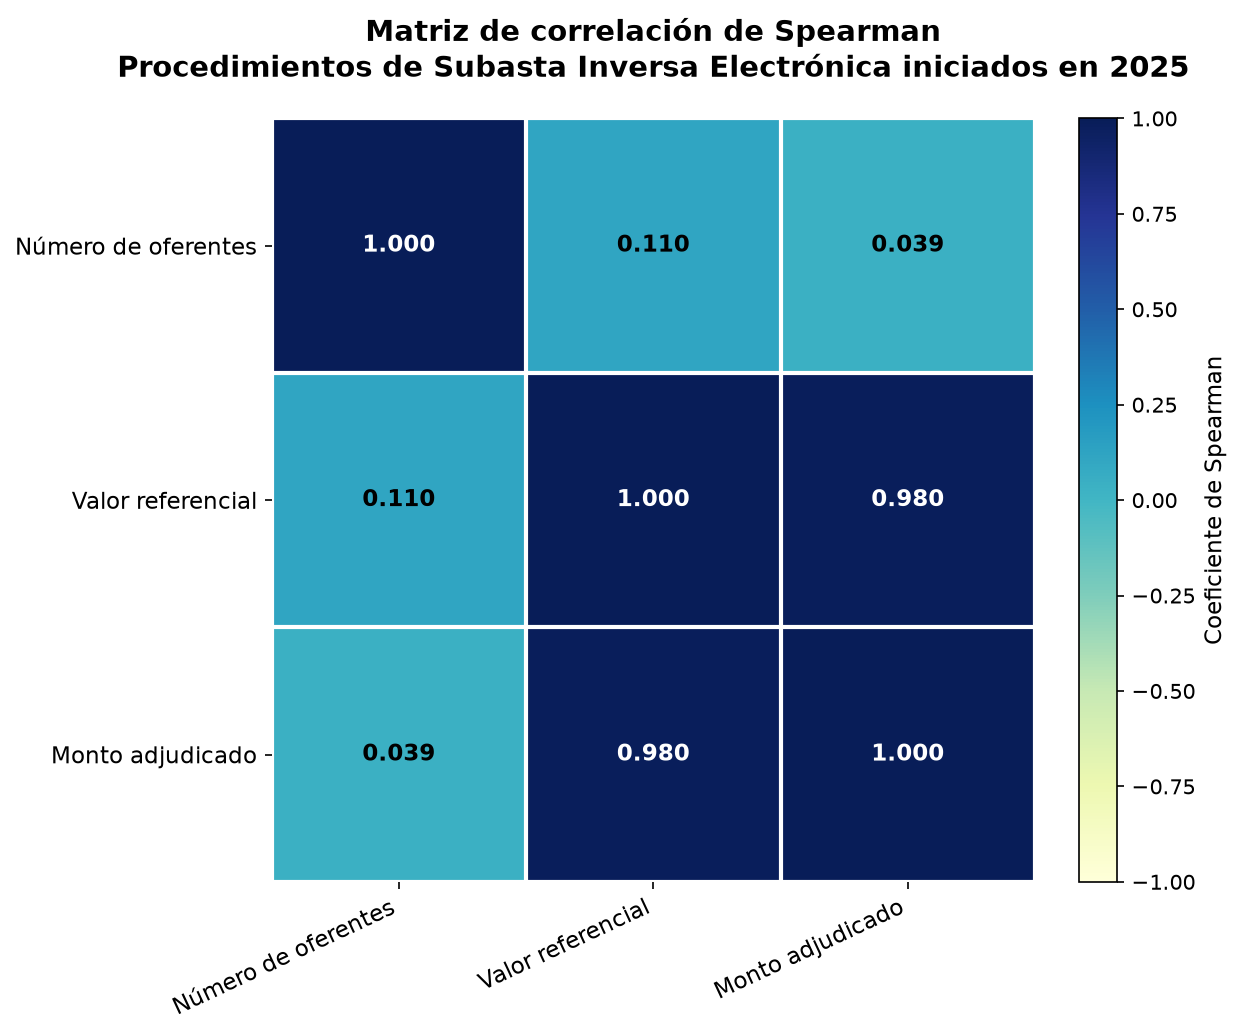

Figura guardada en:
/Users/dianaaltamirano/PycharmProjects/analitica_redes_contratacion_ecuador_2025/reports/figures/matriz_correlacion_spearman_procedimientos_2025_v2.png

¿El archivo existe?
True

Tamaño del archivo en bytes:
171811


In [39]:
# ============================================================
# PASO 10. VISUALIZACIÓN MEJORADA DE LA MATRIZ DE CORRELACIÓN
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Copia de la matriz con nombres más amigables
matriz_grafico = matriz_correlacion_spearman.copy()

matriz_grafico.columns = [
    "Número de oferentes",
    "Valor referencial",
    "Monto adjudicado"
]

matriz_grafico.index = [
    "Número de oferentes",
    "Valor referencial",
    "Monto adjudicado"
]

# Convertir a arreglo para graficar
datos = matriz_grafico.values

# Crear figura
fig, ax = plt.subplots(figsize=(9, 7), dpi=150)

# Mapa de calor
imagen = ax.imshow(
    datos,
    cmap="YlGnBu",
    vmin=-1,
    vmax=1
)

# Título
ax.set_title(
    "Matriz de correlación de Spearman\n"
    "Procedimientos de Subasta Inversa Electrónica iniciados en 2025",
    fontsize=14,
    fontweight="bold",
    pad=20
)

# Etiquetas de ejes
ax.set_xticks(np.arange(len(matriz_grafico.columns)))
ax.set_yticks(np.arange(len(matriz_grafico.index)))

ax.set_xticklabels(
    matriz_grafico.columns,
    fontsize=11,
    rotation=25,
    ha="right"
)

ax.set_yticklabels(
    matriz_grafico.index,
    fontsize=11
)

# Agregar valores dentro de las celdas
for i in range(datos.shape[0]):
    for j in range(datos.shape[1]):
        valor = datos[i, j]

        # Color del texto según intensidad del fondo
        color_texto = "white" if abs(valor) > 0.50 else "black"

        ax.text(
            j,
            i,
            f"{valor:.3f}",
            ha="center",
            va="center",
            color=color_texto,
            fontsize=11,
            fontweight="bold"
        )

# Líneas divisorias tipo cuadrícula
ax.set_xticks(np.arange(-.5, len(matriz_grafico.columns), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(matriz_grafico.index), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

# Quitar bordes innecesarios
for spine in ax.spines.values():
    spine.set_visible(False)

# Barra de color
barra = fig.colorbar(imagen, ax=ax, fraction=0.046, pad=0.04)
barra.set_label("Coeficiente de Spearman", fontsize=11)
barra.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


# ============================================================
# GUARDAR LA FIGURA Y COMPROBAR EL ARCHIVO
# ============================================================

ruta_archivo_figura = os.path.join(
    ruta_figuras,
    "matriz_correlacion_spearman_procedimientos_2025_v2.png"
)

# Guardar exactamente la figura creada en este paso.
fig.savefig(
    ruta_archivo_figura,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

print("\n¿El archivo existe?")
print(os.path.exists(ruta_archivo_figura))

print("\nTamaño del archivo en bytes:")
print(os.path.getsize(ruta_archivo_figura))

# Mostrar la figura después de guardarla.
plt.show()

In [41]:
# ============================================================
# PASO 11. NATURALEZA Y ESTRUCTURA DE LOS DATOS
# ============================================================
# Este paso resume las principales características de las
# bases utilizadas en el estudio.
#
# Se documenta:
# - fuente de información,
# - unidad de análisis,
# - cantidad de registros,
# - identificador principal,
# - naturaleza general de las variables.
#
# Esta información permite comprender la estructura relacional
# de los datos antes de realizar los análisis posteriores.
# ============================================================

resumen_naturaleza_datos = pd.DataFrame([

    [
        "Procedimientos",
        "SERCOP - Datos abiertos OCDS",
        "Procedimiento de contratación",
        len(procedimientos_df),
        "ocid",
        "Categóricas, cuantitativas, temporales y binarias",
        "Contiene información general de cada procedimiento, "
        "entidad contratante, participación, valor referencial "
        "y estado de adjudicación."
    ],

    [
        "Participación de oferentes",
        "SERCOP - Datos abiertos OCDS",
        "Procedimiento - oferente",
        len(oferentes_df),
        "ocid + tenderer_id",
        "Principalmente categóricas",
        "Registra la participación de cada oferente en los "
        "procedimientos y permite analizar la estructura de "
        "competencia."
    ],

    [
        "Adjudicaciones",
        "SERCOP - Datos abiertos OCDS",
        "Procedimiento - proveedor adjudicado",
        len(adjudicaciones_df),
        "ocid + award_id + supplier_id",
        "Categóricas, cuantitativas y temporales",
        "Contiene las relaciones entre entidades contratantes "
        "y proveedores adjudicados, montos, fechas y objeto "
        "contractual CPC."
    ]

], columns=[
    "base",
    "fuente",
    "unidad_analisis",
    "numero_registros",
    "identificador_principal",
    "naturaleza_variables",
    "descripcion"
])

display(
    resumen_naturaleza_datos.style
    .hide(axis="index")
    .format({
        "numero_registros": "{:,.0f}"
    })
    .set_properties(**{
        "text-align": "left",
        "white-space": "normal"
    })
)

base,fuente,unidad_analisis,numero_registros,identificador_principal,naturaleza_variables,descripcion
Procedimientos,SERCOP - Datos abiertos OCDS,Procedimiento de contratación,"18,326",ocid,"Categóricas, cuantitativas, temporales y binarias","Contiene información general de cada procedimiento, entidad contratante, participación, valor referencial y estado de adjudicación."
Participación de oferentes,SERCOP - Datos abiertos OCDS,Procedimiento - oferente,"79,425",ocid + tenderer_id,Principalmente categóricas,Registra la participación de cada oferente en los procedimientos y permite analizar la estructura de competencia.
Adjudicaciones,SERCOP - Datos abiertos OCDS,Procedimiento - proveedor adjudicado,"15,718",ocid + award_id + supplier_id,"Categóricas, cuantitativas y temporales","Contiene las relaciones entre entidades contratantes y proveedores adjudicados, montos, fechas y objeto contractual CPC."


In [42]:
# ============================================================
# PASO 12. PERFIL DE LAS VARIABLES CUANTITATIVAS
# ============================================================
# Se resumen las principales características estadísticas de
# las variables cuantitativas utilizadas a nivel de procedimiento.
#
# La mediana, la media y la asimetría permiten identificar si
# las distribuciones son simétricas o presentan concentración
# de observaciones en determinados rangos y valores extremos.
# ============================================================

perfil_variables_cuantitativas = pd.DataFrame([
    {
        "variable": "Número de oferentes",
        "registros_disponibles": base_correlacion["number_of_tenderers"].count(),
        "valores_faltantes": base_correlacion["number_of_tenderers"].isna().sum(),
        "minimo": base_correlacion["number_of_tenderers"].min(),
        "mediana": base_correlacion["number_of_tenderers"].median(),
        "media": base_correlacion["number_of_tenderers"].mean(),
        "maximo": base_correlacion["number_of_tenderers"].max(),
        "asimetria": base_correlacion["number_of_tenderers"].skew()
    },

    {
        "variable": "Valor referencial",
        "registros_disponibles": base_correlacion["tender_value"].count(),
        "valores_faltantes": base_correlacion["tender_value"].isna().sum(),
        "minimo": base_correlacion["tender_value"].min(),
        "mediana": base_correlacion["tender_value"].median(),
        "media": base_correlacion["tender_value"].mean(),
        "maximo": base_correlacion["tender_value"].max(),
        "asimetria": base_correlacion["tender_value"].skew()
    },

    {
        "variable": "Monto adjudicado",
        "registros_disponibles": base_correlacion["award_amount"].count(),
        "valores_faltantes": base_correlacion["award_amount"].isna().sum(),
        "minimo": base_correlacion["award_amount"].min(),
        "mediana": base_correlacion["award_amount"].median(),
        "media": base_correlacion["award_amount"].mean(),
        "maximo": base_correlacion["award_amount"].max(),
        "asimetria": base_correlacion["award_amount"].skew()
    }

])

display(
    perfil_variables_cuantitativas.style
    .hide(axis="index")
    .format({
        "registros_disponibles": "{:,.0f}",
        "valores_faltantes": "{:,.0f}",
        "minimo": "{:,.2f}",
        "mediana": "{:,.2f}",
        "media": "{:,.2f}",
        "maximo": "{:,.2f}",
        "asimetria": "{:.2f}"
    })
)

variable,registros_disponibles,valores_faltantes,minimo,mediana,media,maximo,asimetria
Número de oferentes,"18,033",293,1.00,3.00,4.40,44.00,2.28
Valor referencial,"18,325",1,"7,213.03","39,500.30","117,150.54","15,996,328.00",19.58
Monto adjudicado,"15,718","2,608","1,754.82","32,601.26","95,759.76","12,840,063.97",16.56


In [43]:
# ============================================================
# PASO 13. COBERTURA Y CARDINALIDAD DE LOS DATOS
# ============================================================
# Este paso resume la cantidad de actores y categorías únicas
# presentes en las bases.
#
# La cardinalidad es especialmente relevante para el proyecto,
# ya que permite dimensionar la estructura relacional que
# posteriormente será modelada como red comprador-proveedor.
# ============================================================

resumen_cardinalidad = pd.DataFrame([

    [
        "Procedimientos",
        procedimientos_df["ocid"].nunique(),
        "Número de procedimientos únicos analizados."
    ],

    [
        "Entidades contratantes",
        procedimientos_df["buyer_id"].nunique(),
        "Número de compradores distintos identificados."
    ],

    [
        "Oferentes",
        oferentes_df["tenderer_id"].nunique(),
        "Número de oferentes distintos que participaron en los procedimientos."
    ],

    [
        "Proveedores adjudicados",
        adjudicaciones_df["supplier_id"].nunique(),
        "Número de proveedores distintos que recibieron al menos una adjudicación."
    ],

    [
        "Procedimientos con adjudicación",
        adjudicaciones_df["ocid"].nunique(),
        "Procedimientos que cuentan con un proveedor adjudicado."
    ],

    [
        "CPC a cinco dígitos",
        adjudicaciones_df["cpc_5"].nunique(),
        "Número de categorías distintas de objeto contractual utilizadas en el análisis de recurrencia."
    ]

], columns=[
    "elemento",
    "cantidad",
    "descripcion"
])

display(
    resumen_cardinalidad.style
    .hide(axis="index")
    .format({
        "cantidad": "{:,.0f}"
    })
    .set_properties(**{
        "text-align": "left",
        "white-space": "normal"
    })
)

elemento,cantidad,descripcion
Procedimientos,"18,326",Número de procedimientos únicos analizados.
Entidades contratantes,"1,737",Número de compradores distintos identificados.
Oferentes,"12,125",Número de oferentes distintos que participaron en los procedimientos.
Proveedores adjudicados,"5,969",Número de proveedores distintos que recibieron al menos una adjudicación.
Procedimientos con adjudicación,"15,718",Procedimientos que cuentan con un proveedor adjudicado.
CPC a cinco dígitos,868,Número de categorías distintas de objeto contractual utilizadas en el análisis de recurrencia.


In [44]:
# ============================================================
# PASO 14. CRITERIOS DE INCLUSIÓN EN LA MATRIZ DE CORRELACIÓN
# ============================================================
# No todas las columnas pueden incorporarse válidamente en una
# matriz de correlación.
#
# La correlación de Spearman se aplica a variables con sentido
# cuantitativo u ordinal y que comparten una misma unidad de
# análisis.
#
# Los identificadores, nombres y códigos categóricos se
# excluyen porque sus valores no representan magnitudes.
#
# Las métricas de concentración, recurrencia y red se calculan
# en otras unidades de análisis y, por lo tanto, no deben
# mezclarse directamente con variables a nivel de procedimiento.
# ============================================================

criterios_correlacion = pd.DataFrame([

    [
        "number_of_tenderers",
        "Sí",
        "Procedimiento",
        "Variable cuantitativa discreta con variabilidad y significado estadístico."
    ],

    [
        "tender_value",
        "Sí",
        "Procedimiento",
        "Variable cuantitativa continua correspondiente al valor referencial."
    ],

    [
        "award_amount",
        "Sí",
        "Procedimiento adjudicado",
        "Variable cuantitativa continua correspondiente al monto adjudicado."
    ],

    [
        "ocid, buyer_id, supplier_id, tenderer_id y RUC",
        "No",
        "Identificación",
        "Son identificadores nominales; sus valores no representan cantidades ni orden."
    ],

    [
        "cpc_5",
        "No",
        "Objeto contractual",
        "Es un código categórico. Un número CPC mayor no representa una magnitud mayor."
    ],

    [
        "Nombres y descripciones",
        "No",
        "Categórica",
        "Son variables nominales de texto y no poseen interpretación cuantitativa."
    ],

    [
        "Fechas",
        "No en esta matriz",
        "Temporal",
        "Se utilizan para delimitación y recurrencia; no se transforman arbitrariamente en valores numéricos."
    ],

    [
        "tiene_adjudicacion",
        "No en esta matriz",
        "Procedimiento adjudicado",
        "En la base utilizada para correlación todos los registros tienen adjudicación, por lo que la variable es constante."
    ],

    [
        "HHI, CR4 y entropía",
        "No en esta matriz",
        "Entidad contratante",
        "Se calculan a nivel de entidad contratante y deben analizarse separadamente."
    ],

    [
        "Recurrencia",
        "No en esta matriz",
        "Comprador - proveedor - CPC5",
        "Corresponde a una unidad de análisis distinta del procedimiento."
    ],

    [
        "Degree y betweenness",
        "No en esta matriz",
        "Actor de la red",
        "Son métricas de red que se obtendrán posteriormente a nivel de comprador o proveedor."
    ]

], columns=[
    "variable_o_grupo",
    "incluida_correlacion",
    "unidad_analisis",
    "justificacion"
])

display(
    criterios_correlacion.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "left",
        "white-space": "normal"
    })
)

variable_o_grupo,incluida_correlacion,unidad_analisis,justificacion
number_of_tenderers,Sí,Procedimiento,Variable cuantitativa discreta con variabilidad y significado estadístico.
tender_value,Sí,Procedimiento,Variable cuantitativa continua correspondiente al valor referencial.
award_amount,Sí,Procedimiento adjudicado,Variable cuantitativa continua correspondiente al monto adjudicado.
"ocid, buyer_id, supplier_id, tenderer_id y RUC",No,Identificación,Son identificadores nominales; sus valores no representan cantidades ni orden.
cpc_5,No,Objeto contractual,Es un código categórico. Un número CPC mayor no representa una magnitud mayor.
Nombres y descripciones,No,Categórica,Son variables nominales de texto y no poseen interpretación cuantitativa.
Fechas,No en esta matriz,Temporal,Se utilizan para delimitación y recurrencia; no se transforman arbitrariamente en valores numéricos.
tiene_adjudicacion,No en esta matriz,Procedimiento adjudicado,"En la base utilizada para correlación todos los registros tienen adjudicación, por lo que la variable es constante."
"HHI, CR4 y entropía",No en esta matriz,Entidad contratante,Se calculan a nivel de entidad contratante y deben analizarse separadamente.
Recurrencia,No en esta matriz,Comprador - proveedor - CPC5,Corresponde a una unidad de análisis distinta del procedimiento.
